Ingest and clean cart level data from Vori. This report was extracted from the UI Reports > Item Sales > Underlying data

In [1]:
import pandas as pd
import numpy as numpy
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
os.getcwd()

'/Users/casita/pCloud Drive/pCloud Backup/mofongo-HP-EliteBook-840-G8-Notebook-PC/pCloud_docs/ghfc/merch/merch_analysis_git/cart_analysis'

In [2]:
df = pd.read_csv('./Items with cost(2).csv')

/var/folders/7x/md6t50l11gnfjmmrc6f2f7lr0000gn/T/ipykernel_2837/1483129609.py:1: DtypeWarning: Columns (0: Barcode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./Items with cost(2).csv')


In [5]:
#42 columns is a lot
df.shape

(73951, 42)

In [4]:
#print only the float columns
df.select_dtypes(include=['float64']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73951 entries, 0 to 73950
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   % Items with cost     73951 non-null  float64
 1   Shopper Phone         45 non-null     float64
 2   Product ID            73951 non-null  float64
 3   Each Cost             69752 non-null  float64
 4   Retail Price          73951 non-null  float64
 5   Wic Adjusted Price    0 non-null      float64
 6   Quantity              73951 non-null  float64
 7   Weight                25814 non-null  float64
 8   Promotion Amount      73951 non-null  float64
 9   Items Total           73951 non-null  float64
 10  Bottle Deposits       73951 non-null  float64
 11  Discount and Rewards  73951 non-null  float64
 12  Wic Adjustment        0 non-null      float64
 13  Sales                 73951 non-null  float64
 14  Cost of Goods Sold    69752 non-null  float64
 15  Ebt Tax Exempted   

In [6]:
#attempt to remove spoilage-related order_id 
df = df.assign(order_dt = pd.to_datetime(df['Order Date'], errors = 'coerce'))

/var/folders/7x/md6t50l11gnfjmmrc6f2f7lr0000gn/T/ipykernel_82216/3218756571.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = df.assign(order_dt = pd.to_datetime(df['Order Date'], errors = 'coerce'))


The first step is to identify spoilage and attempt to remove it. Spoilage is expected to be recorded at 100% of the price or cost. Discounted items are OK.

In [8]:
#Order ID is likely on the entire cart, so it's a 1:many on the underlying items
#I'm isolating cases where the ENTIRE 'Order Id' - not just the component items - have negative total value, which implies that the entire cart was comprised of spoilage
sales_sum_df = df.groupby(['order_dt','Order ID']).agg(sales_sum=('Sales','sum')).query('sales_sum <0').reset_index()

In [9]:
#counting the # of negative sales transactions (presumably all spoilage)
sales_sum_df.groupby(sales_sum_df['order_dt'].dt.date).agg(count=('Order ID','nunique')).sort_values('order_dt').head()

,count
order_dt,
2025-10-01,2
2025-10-05,2
2025-10-07,1
2025-10-08,2
2025-10-09,1


In [10]:
#isolate a dataframe of orders that are negative
sales_sum_df1 = df.groupby(['Order ID']).agg(sales_sum=('Sales','sum'),discount_sum=('Discount and Rewards','sum')).query('sales_sum <0').reset_index()

In [11]:
sales_sum_df1.sample(5)

,Order ID,sales_sum,discount_sum
47,GHB1764185200,-8.46,0.00
30,GHA1764635179,-11.91,0.00
48,GHB1764614725,-14.92,0.00
42,GHB1761424386,-2.96,0.74
26,GHA1763513262,-10.63,0.00


In [12]:
#investigate the relationship between negative sales (per Order ID) and 'Discount and Rewards'; ALL negative carts are refunds
sales_sum_df2 = df.query("`Line Type` != 'Refund'").groupby(['Order ID']).agg(sales_sum=('Sales','sum'),discount_sum=('Discount and Rewards','sum')).query('sales_sum <0').reset_index()

<Axes: title={'center': 'distribution of discounts'}, ylabel='Frequency'>

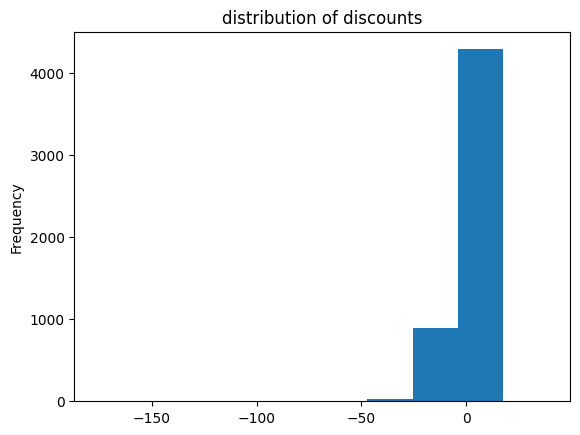

In [13]:
#identify spoilage transactions (all 100% discounted)
df.query("`Discount and Rewards` != 0")['Discount and Rewards'].plot(kind = 'hist', bins = 10, title='distribution of discounts')

In [14]:
#attempt to value all positive value carts
sales_sum_df_pos = df.groupby(['order_dt','Order ID']).agg(sales_sum=('Sales','sum')).query('sales_sum >0').reset_index()

In [16]:
agg_sales_trans = sales_sum_df_pos.groupby([sales_sum_df_pos['order_dt'].dt.normalize()]).agg(avg_basket=('sales_sum','mean'),num_trans=('Order ID','nunique')).reset_index()

<Axes: title={'center': 'Average Basket Value Over Time'}, xlabel='order_dt'>

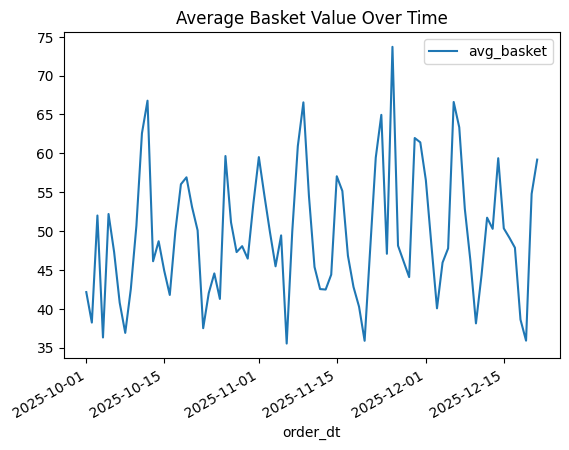

In [17]:
#time series of average basket value by order_dt
agg_sales_trans.plot(kind='line', x='order_dt', y='avg_basket', title='Average Basket Value Over Time')

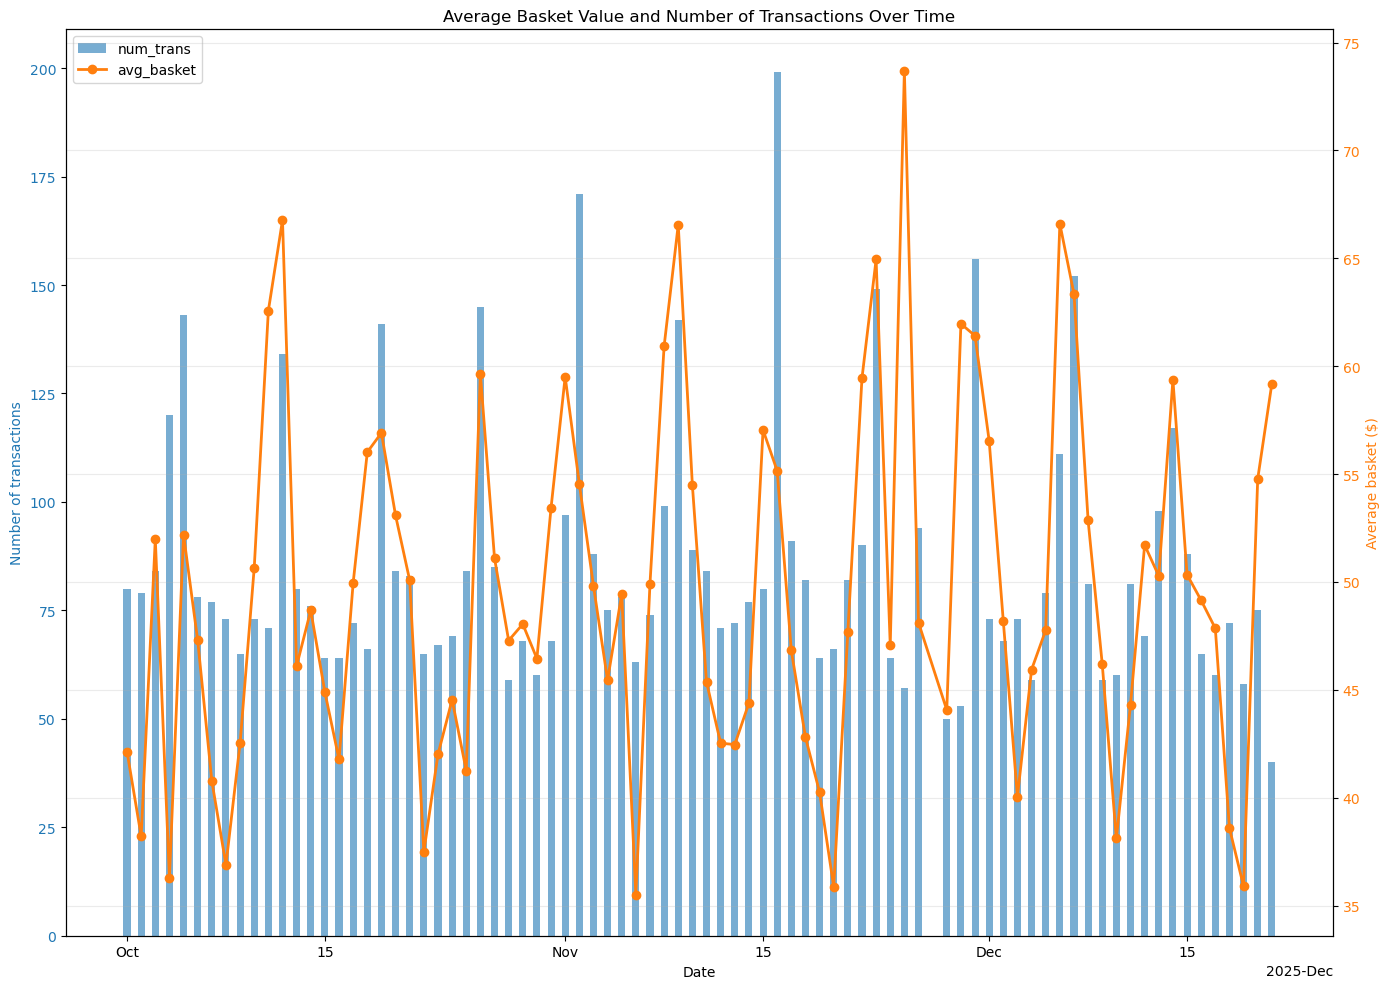

In [25]:
import matplotlib.dates as mdates

# ensure agg_sales_trans exists and order_dt is datetime
agg_sales_trans['order_dt'] = pd.to_datetime(agg_sales_trans['order_dt'])

fig, ax1 = plt.subplots(figsize=(14,10))

# bar plot: number of transactions (vertical bars)
ax1.bar(agg_sales_trans['order_dt'], agg_sales_trans['num_trans'],
        width=0.5, alpha=0.6, color='C0', label='num_trans')
ax1.set_ylabel('Number of transactions', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# format x-axis nicely for dates
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax1.xaxis.get_major_locator()))
ax1.set_xlabel('Date')

# line plot on secondary y-axis: average basket value
ax2 = ax1.twinx()
ax2.plot(agg_sales_trans['order_dt'], agg_sales_trans['avg_basket'],
         marker='o', color='C1', linewidth=2, label='avg_basket')
ax2.set_ylabel('Average basket ($)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

# combined legend and layout
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.title('Average Basket Value and Number of Transactions Over Time')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Recreate the above plot but partition by day of week, as there appears to be strong seasonality

In [18]:
cols = ['Barcode','Brand','Department','Items Total','Order Date',
'Product ID','Quantity','Sub-Department','Order ID']
df2 = df.loc[:,cols]
df2.columns = [i.replace(' ','_').lower() for i in cols]

In [19]:
#df2['order_date'].to_dateteime(format="%a",%M %d, %Y, %h:%m %p)
try:
    df2['order_date2'] = pd.to_datetime(df2['order_date'],errors='coerce')
except ValueError as e:
    print(e)

/var/folders/7x/md6t50l11gnfjmmrc6f2f7lr0000gn/T/ipykernel_82216/3822103420.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['order_date2'] = pd.to_datetime(df2['order_date'],errors='coerce')


In [20]:
first = df2.groupby([df2['order_date2'].dt.normalize()])['order_id'].nunique().reset_index()


In [22]:
#measure the average number of carts by day of week and month-year
first_gb = first.groupby([first['order_date2'].dt.month,first['order_date2'].dt.dayofweek])['order_id'].mean()
first_gb.index.names = ['month', 'dayofweek']
first_gb = first_gb.reset_index()

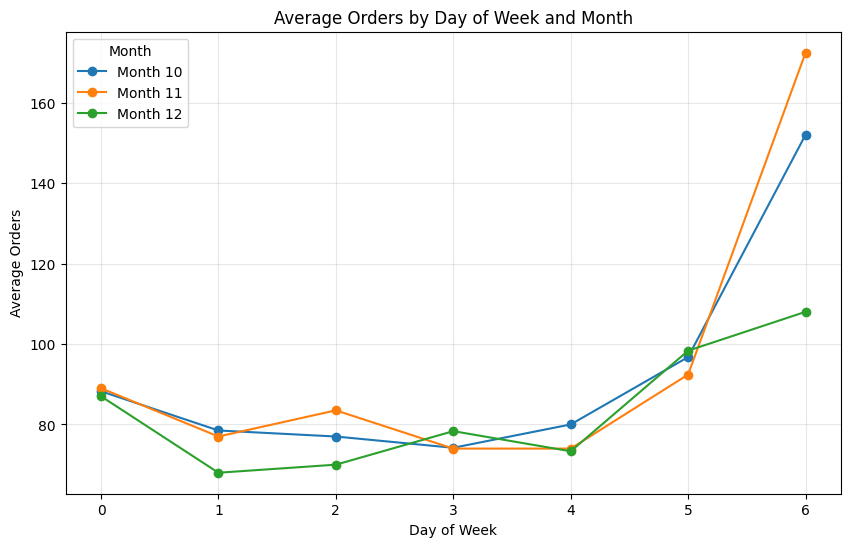

In [23]:
pivot_data = first_gb.pivot(index='dayofweek', columns='month', values='order_id')

plt.figure(figsize=(10, 6))
pivot_data.plot(ax=plt.gca(), marker='o')

plt.xlabel('Day of Week')
plt.ylabel('Average Orders')
plt.title('Average Orders by Day of Week and Month')
plt.legend(title='Month', labels=[f'Month {int(m)}' for m in pivot_data.columns])
plt.grid(True, alpha=0.3)
plt.show()

## Barcode level analysis

- **correlation** between barcodes and # of carts per week: to determine "habituation", ie should a customer come in to buy a a barcode does that drive more visits? The more visits that include that item, the more habituation. I wonder if I can build a correlation chart? I need to look into the formula
- **correlation** between barcodes and value of cart
- *"reach"*: given the presence of a barcode, how many other categories are purchased/included in cart

In [1]:
import pandas as pd
import numpy as numpy
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cart_analysis_package.df_transforms as df_transforms

In [9]:
df = pd.read_csv('./Items with cost(2).csv')
df = df_transforms.clean_df(df)
df = df_transforms.subset_shopping(df)

/var/folders/7x/md6t50l11gnfjmmrc6f2f7lr0000gn/T/ipykernel_16430/1265533612.py:1: DtypeWarning: Columns (0: Barcode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./Items with cost(2).csv')
/Users/casita/Documents/gitdev/merchAnalysis/cart_analysis/cart_analysis_package/df_transforms.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')


## Analytical approach from 5/17
- proportion of total orders having sub_dept (requires counting unique `order_ids` over measurement period, then counting unique `order_id` having the sub_dept)
- "repertoire": (#of other subs|appearance of sub_dept in cart)
- cart value relationships: (distribution of cart value|appearance of sub_dept in cart) 

In [10]:
df.dtypes

barcode                   object
brand                        str
department                   str
items_total              float64
order_date        datetime64[us]
product_id               float64
quantity                 float64
sub-department               str
order_id                     str
sales                    float64
dtype: object

In [55]:
#df = df.assign(order_date=df['order_date'].dt.date)
#make a list of unique sub_dept and place in a series
df_list_sub = df.groupby(['order_id','order_date'])['sub-department'].unique().reset_index()

#it might be easier to cut this dataframe from the opposite perspective: # of order_ids by date grouping by sub-department
df_order_by_sub_date = df.groupby(['sub-department','order_date'])['order_id'].nunique().reset_index()

#context/level-of-detail challenge: consider the # of unique order_id by order_date
df_orders_by_date = df.groupby('order_date')['order_id'].nunique().reset_index()

df_final = df_order_by_sub_date.merge(df_orders_by_date, on='order_date', how='left')

In [ ]:
#TODO: validate the two calculated columns here
df_final.head()

,sub-department,order_date,order_id_x,order_id_y
0,ALCOHOLIC BEVERAGES,2025-10-04,54,126
1,ALCOHOLIC BEVERAGES,2025-10-17,1,77
2,ALCOHOLIC BEVERAGES,2025-10-23,1,74
3,ALCOHOLIC BEVERAGES,2025-10-31,1,73
4,ALCOHOLIC BEVERAGES,2025-11-30,2,165


In [ ]:
#rename columns for clarity
df_list_sub.columns = ['order_id','order_date','unique_sub_dept_list']

In [39]:
#get date range in order to subset the max range for a test measurement window
#2025-10-01 to 2025-12-21
df_list_sub['order_date'].agg(['min', 'max'])


min    2025-10-01
max    2025-12-21
Name: order_date, dtype: object

In [40]:
df_list_sub.dtypes

order_id                   str
order_date              object
unique_sub_dept_list    object
dtype: object

In [41]:
df_list_sub.head(3)

,order_id,order_date,unique_sub_dept_list
0,GHA1759336259,2025-10-01,[Oral Care]
1,GHA1759336291,2025-10-01,[Oral Care]
2,GHA1759336383,2025-10-01,[Oral Care]


In [48]:
display(df_list_sub.loc[df_list_sub['order_date'] == pd.Timestamp('2025-10-01').date(),:])

,order_id,order_date,unique_sub_dept_list
0,GHA1759336259,2025-10-01,[Oral Care]
1,GHA1759336291,2025-10-01,[Oral Care]
2,GHA1759336383,2025-10-01,[Oral Care]
3,GHA1759337197,2025-10-01,[Produce Fruit]
4,GHA1759337630,2025-10-01,[Soft Drinks]
...,...,...,...
6108,GHB1759361181,2025-10-01,"[Water, Sparkling]"
6109,GHB1759361383,2025-10-01,"[Bags, Cheese, Chips, Shelf Stable, PRODUCE, P..."
6110,GHB1759361508,2025-10-01,"[Water, Sparkling]"
6111,GHB1759362641,2025-10-01,"[Oral Care, Household, PRODUCE, Produce Fruit,..."


### Per order_id calculate:
- total value
- number of total items
- number of items per sub-department
- list of unique sub-department

In [3]:
#context challenges (aka level of detail)
# order_id total
# sub-department item count

sub_data = df.groupby(['order_id','sub-department']).agg(
    sub_dept_distinct_products=('sub-department','count'), #think I can get away with this bc Vori rolls up items to barcode @ the register
    sub_dep_total_item_cnt=('quantity','sum')
)

order_level_sales = df.groupby('order_id').agg(
    total_sales_order=('sales','sum')).query('total_sales_order>0')

#df.groupby(['order_id','sub-department']).agg

In [7]:
df.loc[df['order_id']=='GHA1759338261',]

,barcode,brand,department,items_total,order_date,product_id,quantity,sub-department,order_id,sales
1911,9421905614382,Compostic,NONFOOD,6.69,"Wed, Oct 01, 2025, 1:04 PM",4142461.0,1.0,Bags,GHA1759338261,6.69
38295,94048,NaN,PRODUCE,1.20,"Wed, Oct 01, 2025, 1:04 PM",1437458.0,2.0,PRODUCE,GHA1759338261,1.20
38935,94053,NaN,PRODUCE,0.89,"Wed, Oct 01, 2025, 1:04 PM",1437456.0,1.0,PRODUCE,GHA1759338261,0.89
41095,770009010200,If You Care,NONFOOD,6.53,"Wed, Oct 01, 2025, 1:04 PM",1434727.0,1.0,Paper Products,GHA1759338261,6.53
45429,40964,NaN,PRODUCE,2.83,"Wed, Oct 01, 2025, 1:04 PM",1437314.0,1.0,Produce Allium,GHA1759338261,2.83


In [ ]:
sub_data.head(10)

sub_dept_distinct_products  \
order_id      sub-department                                    
GHA1759336259 Oral Care                                     1   
GHA1759336291 Oral Care                                     1   
GHA1759336383 Oral Care                                     1   
GHA1759337197 Produce Fruit                                 2   
GHA1759337630 Soft Drinks                                   1   
GHA1759338261 Bags                                          1   
              PRODUCE                                       2   
              Paper Products                                1   
              Produce Allium                                1   
GHA1759338341 Juice, Refrigerated                           1   

                                   sub_dep_total_item_cnt  
order_id      sub-department                               
GHA1759336259 Oral Care                              -1.0  
GHA1759336291 Oral Care                               1.0  
GHA1759336383 Oral Care                               1.0  
GHA1759337197 Produce Fruit                           2.0  
GHA1759337630 Soft Drinks                             1.0  
GHA1759338261 Bags                                    1.0  
              PRODUCE                                 3.0  
              Paper Products                          1.0  
              Produce Allium                          1.0  
GHA1759338341 Juice, Refrigerated                     1.0

In [ ]:
#attempt to form list of dictionaries for ea order_id

In [12]:
test = sub_data.iloc[2:9,:]
test.head(-3)

,,sub_dept_distinct_products,sub_dep_total_item_cnt
order_id,sub-department,,
GHA1759336383,Oral Care,1,1.0
GHA1759337197,Produce Fruit,2,2.0
GHA1759337630,Soft Drinks,1,1.0
GHA1759338261,Bags,1,1.0


In [ ]:
df_m = test.to_dict(orient='index')
display(df_m)

def process_row(k,v):
    new_dict = {k[0]:{k[1]:v}}
    return new_dict

lista = list()
for k,v in df_m.items():
    lista.append(process_row(k,v))

display(lista)

#make a dataframe out of this, then use a kind of groupby to append dictionaries, then conduct some analysis


{('GHA1759336383', 'Oral Care'): {'sub_dept_distinct_products': 1,
  'sub_dep_total_item_cnt': 1.0},
 ('GHA1759337197', 'Produce Fruit'): {'sub_dept_distinct_products': 2,
  'sub_dep_total_item_cnt': 2.0},
 ('GHA1759337630', 'Soft Drinks'): {'sub_dept_distinct_products': 1,
  'sub_dep_total_item_cnt': 1.0},
 ('GHA1759338261', 'Bags'): {'sub_dept_distinct_products': 1,
  'sub_dep_total_item_cnt': 1.0},
 ('GHA1759338261', 'PRODUCE'): {'sub_dept_distinct_products': 2,
  'sub_dep_total_item_cnt': 3.0},
 ('GHA1759338261', 'Paper Products'): {'sub_dept_distinct_products': 1,
  'sub_dep_total_item_cnt': 1.0},
 ('GHA1759338261', 'Produce Allium'): {'sub_dept_distinct_products': 1,
  'sub_dep_total_item_cnt': 1.0}}

[{'GHA1759336383': {'Oral Care': {'sub_dept_distinct_products': 1,
    'sub_dep_total_item_cnt': 1.0}}},
 {'GHA1759337197': {'Produce Fruit': {'sub_dept_distinct_products': 2,
    'sub_dep_total_item_cnt': 2.0}}},
 {'GHA1759337630': {'Soft Drinks': {'sub_dept_distinct_products': 1,
    'sub_dep_total_item_cnt': 1.0}}},
 {'GHA1759338261': {'Bags': {'sub_dept_distinct_products': 1,
    'sub_dep_total_item_cnt': 1.0}}},
 {'GHA1759338261': {'PRODUCE': {'sub_dept_distinct_products': 2,
    'sub_dep_total_item_cnt': 3.0}}},
 {'GHA1759338261': {'Paper Products': {'sub_dept_distinct_products': 1,
    'sub_dep_total_item_cnt': 1.0}}},
 {'GHA1759338261': {'Produce Allium': {'sub_dept_distinct_products': 1,
    'sub_dep_total_item_cnt': 1.0}}}]

In [23]:
df_m[2]

KeyError: 2

In [ ]:
assert(df_m.shape[0] == test.index.nunique())
assert(len(df_m.loc[df['order_id'] == 'GHA1759338261','data'])==4)

,sub-department,sub_dept_distinct_products,sub_dep_total_item_cnt
order_id,,,
GHA1759336383,Oral Care,1,1.0
GHA1759337197,Produce Fruit,2,2.0
GHA1759337630,Soft Drinks,1,1.0
GHA1759338261,Bags,1,1.0
GHA1759338261,PRODUCE,2,3.0
GHA1759338261,Paper Products,1,1.0
GHA1759338261,Produce Allium,1,1.0
GHA1759338341,"Juice, Refrigerated",1,1.0


In [ ]:
# Prereq: df_totransform = sub_data.reset_index('sub-department')  → index = order_id;
# columns: 'sub-department', 'sub_dept_distinct_products', 'sub_dep_total_item_cnt'.
# Goal: one row per order_id with sub_dep_data = list of {sub_dept: NamedTuple(...)}.

from collections import namedtuple

SubDepMetrics = namedtuple(
    'SubDepMetrics',
    ['sub_dept_distinct_products', 'sub_dep_total_item_cnt'],
)

# --- Suggestion 1: groupby().apply() pipeline ---
# Summary: stays in a single pandas chain; compact for notebooks once the lambda is trusted.
df_subdep_nested_1 = (
    df_totransform.reset_index()
    .groupby('order_id', sort=False)
    .apply(
        lambda g: [
            {sub: SubDepMetrics(d, q)}
            for sub, d, q in zip(
                g['sub-department'],
                g['sub_dept_distinct_products'],
                g['sub_dep_total_item_cnt'],
            )
        ],
    )
    .rename('sub_dep_data')
    .reset_index()
)

# --- Suggestion 2: explicit loop + list of dict rows ---
# Summary: imperative flow—easy to log, breakpoint, or change per-order rules without fighting apply().
rows = []
for order_id, g in df_totransform.reset_index().groupby('order_id', sort=False):
    sub_dep_data = [
        {sub: SubDepMetrics(d, q)}
        for sub, d, q in zip(
            g['sub-department'],
            g['sub_dept_distinct_products'],
            g['sub_dep_total_item_cnt'],
        )
    ]
    rows.append({'order_id': order_id, 'sub_dep_data': sub_dep_data})
df_subdep_nested_2 = pd.DataFrame(rows)


In [8]:
#can I create a dictionary out of a column in df in order to consolidate all data on the same order_id?
?pd.DataFrame.reset_index

Signature:
pd.DataFrame.reset_index(
    self,
    level: 'IndexLabel | None' = None,
    *,
    drop: 'bool' = False,
    inplace: 'bool' = False,
    col_level: 'Hashable' = 0,
    col_fill: 'Hashable' = '',
    allow_duplicates: 'bool | lib.NoDefault' = <no_default>,
    names: 'Hashable | Sequence[Hashable] | None' = None,
) -> 'DataFrame | None'
Docstring:
Reset the index, or a level of it.

Reset the index of the DataFrame, and use the default one instead.
If the DataFrame has a MultiIndex, this method can remove one or more
levels.

Parameters
----------
level : int, str, tuple, or list, default None
    Only remove the given levels from the index. Removes all levels by
    default.
drop : bool, default False
    Do not try to insert index into dataframe columns. This resets
    the index to the default integer index.
inplace : bool, default False
    Whether to modify the DataFrame rather than creating a new one.
col_level : int or str, default 0
    If the columns have multipl

In [36]:
sorted(df['department'].unique())

['ALCOHOLIC BEVERAGES',
 'BREAD',
 'BULK',
 'DAIRY',
 'DONATIONS AND STORE CREDIT',
 'DRINKS',
 'GROCERY',
 'MEAT',
 'NONFOOD',
 'PERSONAL CARE',
 'PET SUPPLY',
 'PRODUCE',
 'Produce, Frozen',
 'SEAFOOD',
 'SUPPLEMENTS',
 'Vegan Dairy, Refrig']

In [34]:
sorted(df['sub-department'].unique())

['ALCOHOLIC BEVERAGES',
 'BREAD',
 'BULK',
 'Bags',
 'Baking, Shelf Stable',
 'Bars, Chocolate, Shelf Stable',
 'Bars, Nutritional, Shelf Stable',
 'Beans, Bulk',
 'Beef',
 'Beer',
 "Bob's, Shelf Stable",
 'Bread',
 'Bread, Frozen',
 'Bread, Loaf',
 'Bread, Pastry',
 'Bread, Refrig',
 'Butter',
 'Candy, Shelf Stable',
 'Cat Food, Shelf Stable',
 'Cereal, Shelf Stable',
 'Cheese',
 'Chips, Shelf Stable',
 'Cleaning Supplies',
 'Cleaning/Personal Care, Bulk',
 'Coffee, Bulk',
 'Coffee, Shelf Stable',
 'Condiments, Shelf Stable',
 'Cookies, Shelf Stable',
 'Cooking Sauces, Shelf Stable',
 'Crackers, Shelf Stable',
 'Cream',
 'DAIRY',
 'DONATIONS AND STORE CREDIT',
 'DRINKS',
 'Dairy Alt, Refrig',
 'Deodorant & Shaving',
 'Dessert, Frozen',
 'Dog Food, Shelf Stable',
 'Donation',
 'Dried Fruit, Veg & Nuts Shelf Stable',
 'Eggs',
 'Fermented, Refrig',
 'Flours/Baking, Bulk',
 'Fruit Spreads, Shelf Stable',
 'Fruits, Bulk',
 'GROCERY',
 'Grains, Bulk',
 'Granola/Muesli, Bulk',
 'Hair Care',


In [38]:
df['sub-department'][df['sub-department'].str.contains('Snacks')].unique()

<StringArray>
['Snacks, Bulk', 'Snacks, Shelf Stable']
Length: 2, dtype: str

In [44]:
df.loc[df['sub-department']== 'Snacks, Shelf Stable',['brand', 'product_name', 'sub-department']].drop_duplicates().sort_values('brand')

,brand,product_name,sub-department
66895,Back to Nature,"Crackers, Multigrain Flatbread, 5oz, Back to N...","Snacks, Shelf Stable"
66677,Back to Nature,"Crackers, OG, Saltine, Back to Nature","Snacks, Shelf Stable"
67444,Barbaras,"Cheese Puffs, Original, 7oz, Barbara's","Snacks, Shelf Stable"
67149,Barbaras,"Puffs, Cheese, Jalapeno, 7oz, Barbara's","Snacks, Shelf Stable"
67546,Bjorn Qorn,"Popcorn, Spicy, 3oz, Bjorn Qorn","Snacks, Shelf Stable"
67218,Bjorn Qorn,"Popcorn, Classic, 1oz, Bjorn Qorn","Snacks, Shelf Stable"
66717,Bjorn Qorn,"Popcorn, Classic, 3oz, Bjorn Qorn","Snacks, Shelf Stable"
66631,Boulder,"Chips, Sour Cream and Onion, Boulder, 5oz","Snacks, Shelf Stable"
67069,Chomps,"Beef Stick, Jalapeno, 1.15 oz, Chomps","Snacks, Shelf Stable"
67346,Chomps,"Beef Stick, Sea Salt, 1.15 oz, Chomps","Snacks, Shelf Stable"
